<a href="https://colab.research.google.com/github/debasish-dash-create/DataAnalytics/blob/main/Trader_Performance_vs_Market_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading the DATA

In [19]:
prev_trades = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

#Documenting the DATA

In [20]:
print("=====Previous_Trades=====\n")
print(f"Rows: {prev_trades.shape[0]}, Columns: {prev_trades.shape[1]}")
print("----Missing values:\n", prev_trades.isnull().sum())
print(f"----Duplicates: {prev_trades.duplicated().sum()}\n")

print("=====Fear_Greed=====\n")
print(f"Rows: {fg.shape[0]}, Columns: {fg.shape[1]}")
print("----Missing values:\n", fg.isnull().sum())
print(f"----Duplicates: {fg.duplicated().sum()}")

=====Previous_Trades=====

Rows: 211224, Columns: 16
----Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
----Duplicates: 0

=====Fear_Greed=====

Rows: 2644, Columns: 4
----Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64
----Duplicates: 0


# Conclusion:


*   No missing values/duplicates in both the files





# Understanding the DATA

In [21]:
prev_trades.info()
fg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [22]:
# Parse trade timestamps — format is "DD-MM-YYYY HH:MM"
prev_trades['Timestamp IST'] = pd.to_datetime(prev_trades['Timestamp IST'], dayfirst=True)
prev_trades['date'] = prev_trades['Timestamp IST'].dt.date.astype(str)

# Fear & Greed date column is already clean
fg['date'] = pd.to_datetime(fg['date']).dt.date.astype(str)

# Check date overlap
trade_dates = set(prev_trades['date'].unique())
fg_dates    = set(fg['date'].unique())
overlap = trade_dates & fg_dates
print(f"Overlapping days: {len(overlap)}")

Overlapping days: 479


In [23]:
prev_trades['is_win'] = (prev_trades['Closed PnL'] > 0).astype(int)

# Merge with Fear & Greed
merged = prev_trades.merge(fg[['date', 'value', 'classification']], on='date', how='inner')
merged = merged.rename(columns={'value': 'fg_score', 'classification': 'fg_label'})

print(f"Merged rows: {len(merged)}")
print(merged['fg_label'].value_counts())

Merged rows: 211218
fg_label
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


# Aggregation

In [24]:

daily = merged.groupby(['Account', 'date', 'fg_score', 'fg_label']).agg(
    daily_pnl        = ('Closed PnL', 'sum'),
    num_trades       = ('Trade ID', 'count'),
    avg_size_usd     = ('Size USD', 'mean'),
    total_volume     = ('Size USD', 'sum'),
    win_rate         = ('is_win', 'mean'),
    long_trades      = ('Side', lambda x: (x == 'BUY').sum()),
    short_trades     = ('Side', lambda x: (x == 'SELL').sum()),
).reset_index()

daily['long_short_ratio'] = daily['long_trades'] / (daily['short_trades'] + 1e-6)
daily['is_fear']  = daily['fg_label'].isin(['Fear', 'Extreme Fear'])
daily['is_greed'] = daily['fg_label'].isin(['Greed', 'Extreme Greed'])

print(daily.head())
print(daily.describe())# statistical observation

                                      Account        date  fg_score  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        76   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17        90   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18        83   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22        94   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26        79   

        fg_label  daily_pnl  num_trades  avg_size_usd  total_volume  win_rate  \
0  Extreme Greed        0.0         177   5089.718249     900880.13  0.000000   
1  Extreme Greed        0.0          68   7976.664412     542413.18  0.000000   
2  Extreme Greed        0.0          40  23734.500000     949380.00  0.000000   
3  Extreme Greed   -21227.0          12  28186.666667     338240.00  0.000000   
4  Extreme Greed     1603.1          27  17248.148148     465700.00  0.444444   

   long_trades  short_trades  long_short_ratio  is_fear  is_greed  
0            0    

#PnL and WIN rate on Fear vs Greed days

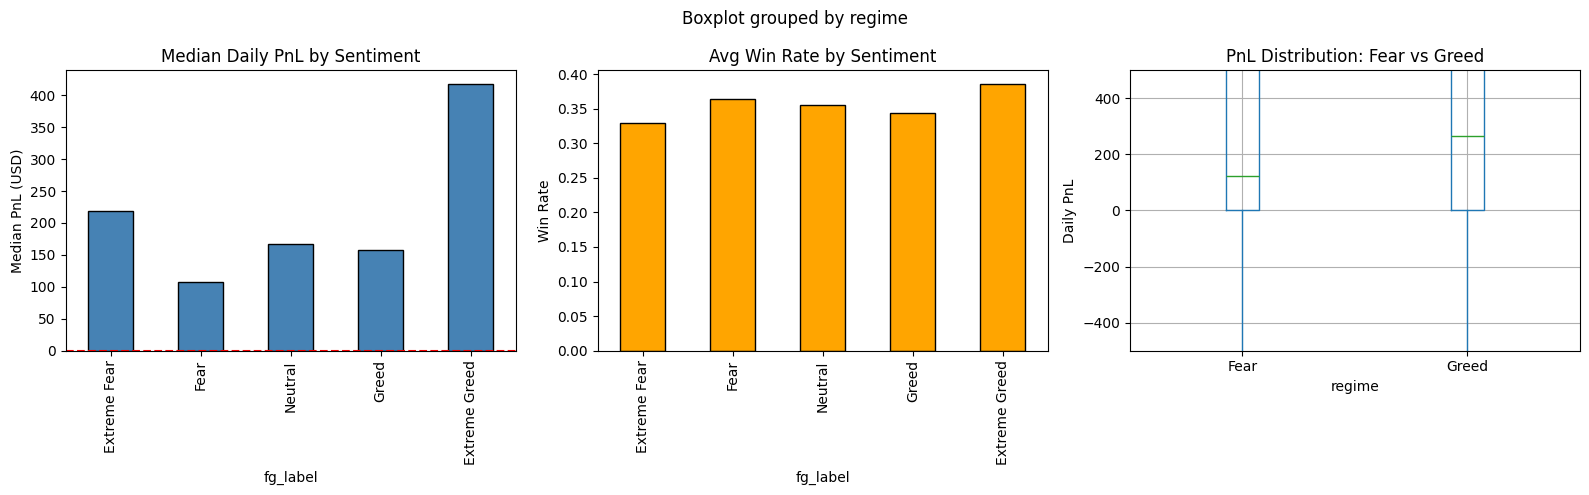

                      mean      median            min            max  \
fg_label                                                               
Extreme Fear   4619.439053  218.377399  -77308.420095  229058.684298   
Extreme Greed  5161.922644  418.319862 -132271.000000  449328.107544   
Fear           5328.818161  107.892532 -108604.496278  533974.662903   
Greed          3318.100730  158.214922 -358963.139984  375620.270243   
Neutral        3438.618818  167.551743 -113601.020138  194499.072534   

                        std  
fg_label                     
Extreme Fear   29534.839183  
Extreme Greed  27496.863832  
Fear           31659.771538  
Greed          30599.040173  
Neutral        17447.863645  


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Median daily PnL by sentiment
pnl_by_sent = daily.groupby('fg_label')['daily_pnl'].median().reindex(
    ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
pnl_by_sent.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='k')
axes[0].set_title('Median Daily PnL by Sentiment')
axes[0].set_ylabel('Median PnL (USD)')
axes[0].axhline(0, color='red', linestyle='--')

# 2. Win rate by sentiment
wr_by_sent = daily.groupby('fg_label')['win_rate'].mean().reindex(
    ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
wr_by_sent.plot(kind='bar', ax=axes[1], color='orange', edgecolor='k')
axes[1].set_title('Avg Win Rate by Sentiment')
axes[1].set_ylabel('Win Rate')

# 3. PnL distribution: Fear vs Greed (binary)
daily_fg = daily[daily['fg_label'].isin(['Fear', 'Extreme Fear', 'Greed', 'Extreme Greed'])].copy()
daily_fg['regime'] = daily_fg['fg_label'].apply(
    lambda x: 'Fear' if 'Fear' in x else 'Greed')
daily_fg.boxplot(column='daily_pnl', by='regime', ax=axes[2])
axes[2].set_title('PnL Distribution: Fear vs Greed')
axes[2].set_ylabel('Daily PnL')
axes[2].set_ylim(-500, 500)  # adjust if needed

plt.tight_layout()
plt.savefig('pnl_by_sentiment.png', dpi=150)
plt.show()

# Drawdown proxy: worst daily PnL per regime
print(daily.groupby('fg_label')['daily_pnl'].agg(['mean','median','min','max','std']))

#Behavioral changes by sentiment

               avg_trades_per_day  avg_position_size     avg_volume  \
fg_label                                                              
Extreme Fear           133.750000        6773.464125  715526.634000   
Fear                    98.153968        8975.928546  767182.206016   
Neutral                100.228723        6963.694861  479367.189043   
Greed                   77.628086        6427.866594  445343.356049   
Extreme Greed           76.030418        5371.637182  236625.788156   

               avg_ls_ratio  
fg_label                     
Extreme Fear   1.073750e+07  
Fear           5.596827e+06  
Neutral        4.550534e+06  
Greed          4.331792e+06  
Extreme Greed  4.467682e+06  


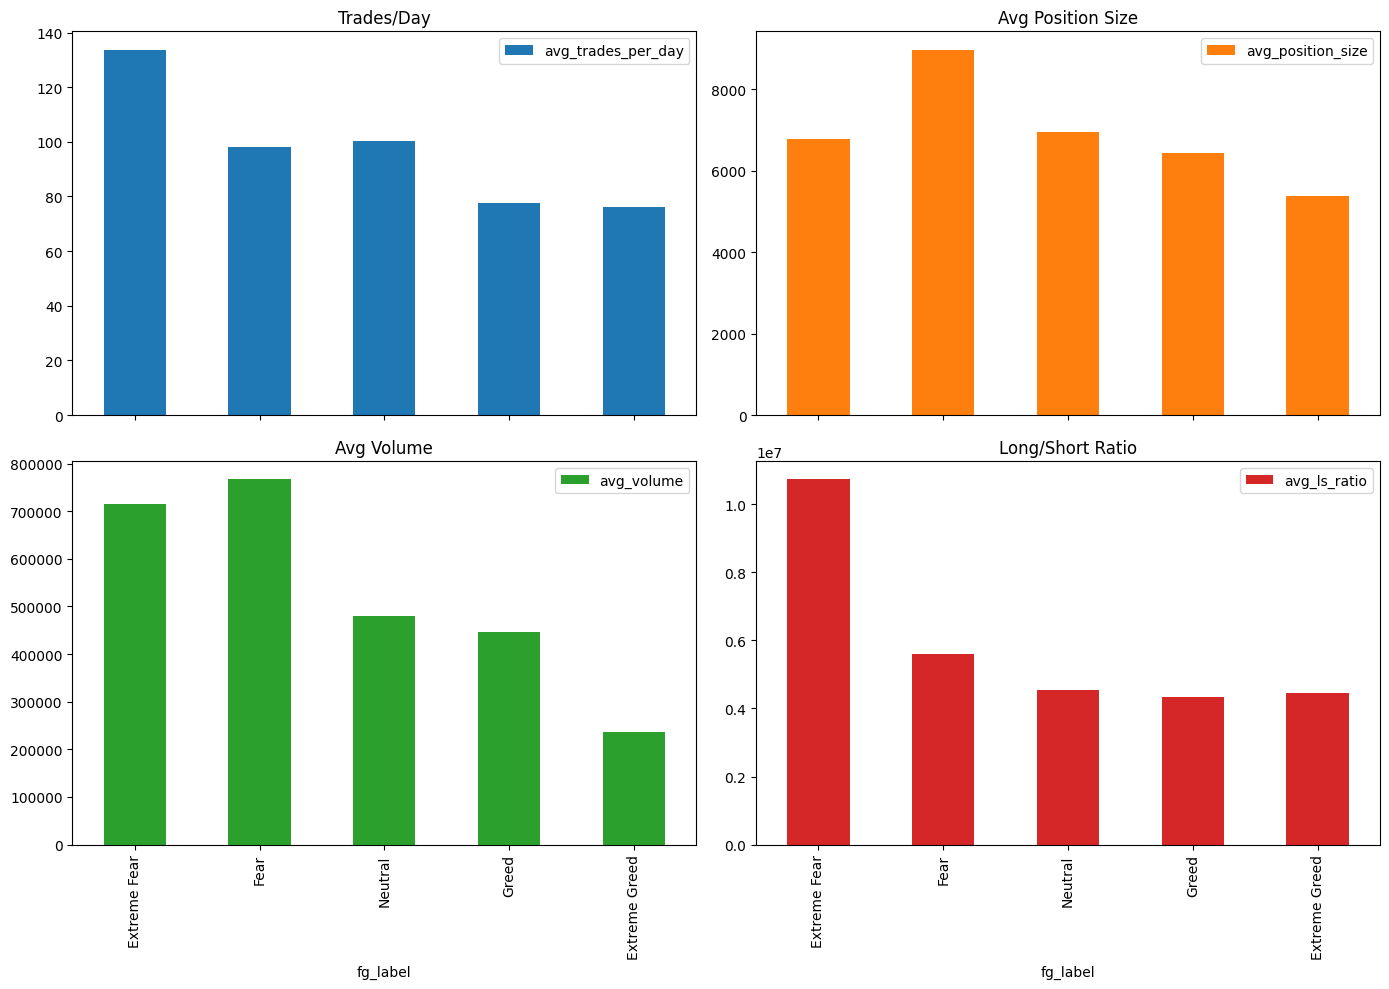

In [26]:
behavior = daily.groupby('fg_label').agg(
    avg_trades_per_day = ('num_trades', 'mean'),
    avg_position_size  = ('avg_size_usd', 'mean'),
    avg_volume         = ('total_volume', 'mean'),
    avg_ls_ratio       = ('long_short_ratio', 'mean'),
).reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

print(behavior)
behavior.plot(subplots=True, figsize=(14, 10), kind='bar', layout=(2,2),
              title=['Trades/Day', 'Avg Position Size', 'Avg Volume', 'Long/Short Ratio'])
plt.tight_layout()
plt.savefig('behavior_by_sentiment.png', dpi=150)
plt.show()

#Trader Segmentation

In [27]:
# Aggregate per trader across all days
trader = daily.groupby('Account').agg(
    total_pnl      = ('daily_pnl', 'sum'),
    avg_daily_pnl  = ('daily_pnl', 'mean'),
    pnl_std        = ('daily_pnl', 'std'),
    avg_win_rate   = ('win_rate', 'mean'),
    avg_size       = ('avg_size_usd', 'mean'),
    avg_trades     = ('num_trades', 'mean'),
    total_days     = ('date', 'count'),
).reset_index()

trader['pnl_std'] = trader['pnl_std'].fillna(0)

# Segment 1: High vs Low Leverage
trader['size_segment'] = pd.qcut(trader['avg_size'], q=3,
                                  labels=['Low Size', 'Mid Size', 'High Size'])

# Segment 2: Frequent vs Infrequent traders
trader['freq_segment'] = pd.qcut(trader['avg_trades'], q=3,
                                  labels=['Infrequent', 'Moderate', 'Frequent'])

# Segment 3: Consistent Winners vs Others
trader['winner'] = trader['avg_win_rate'] >= 0.5
trader['consistent'] = (trader['pnl_std'] < trader['pnl_std'].median()) & trader['winner']
trader['trader_type'] = 'Inconsistent'
trader.loc[trader['winner'] & trader['consistent'], 'trader_type'] = 'Consistent Winner'
trader.loc[trader['winner'] & ~trader['consistent'], 'trader_type'] = 'Volatile Winner'
trader.loc[~trader['winner'], 'trader_type'] = 'Loser'

print(trader['trader_type'].value_counts())
print(trader['size_segment'].value_counts())
print(trader['freq_segment'].value_counts())

trader_type
Loser                31
Consistent Winner     1
Name: count, dtype: int64
size_segment
Low Size     11
High Size    11
Mid Size     10
Name: count, dtype: int64
freq_segment
Infrequent    11
Frequent      11
Moderate      10
Name: count, dtype: int64


#Insight Charts

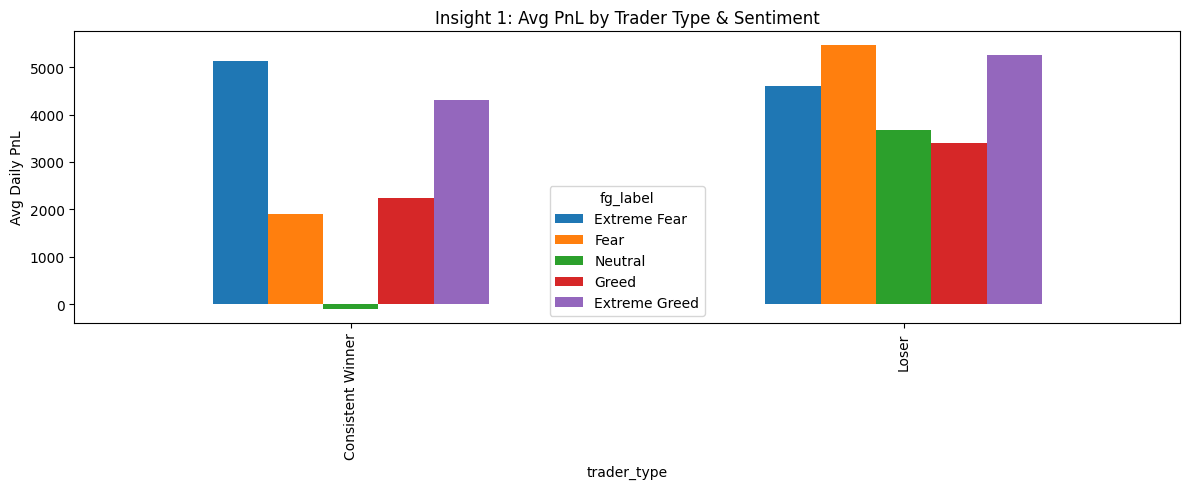

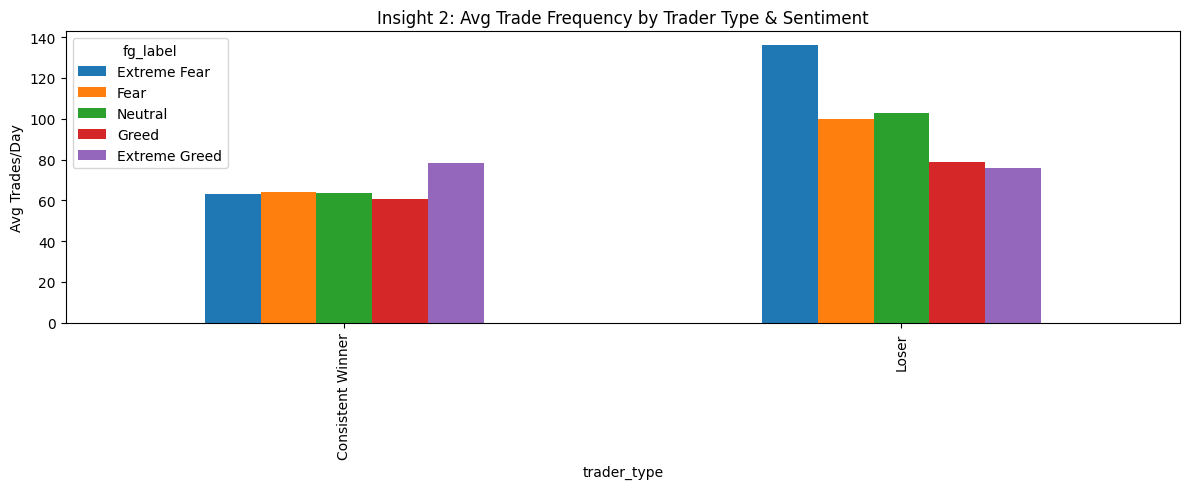

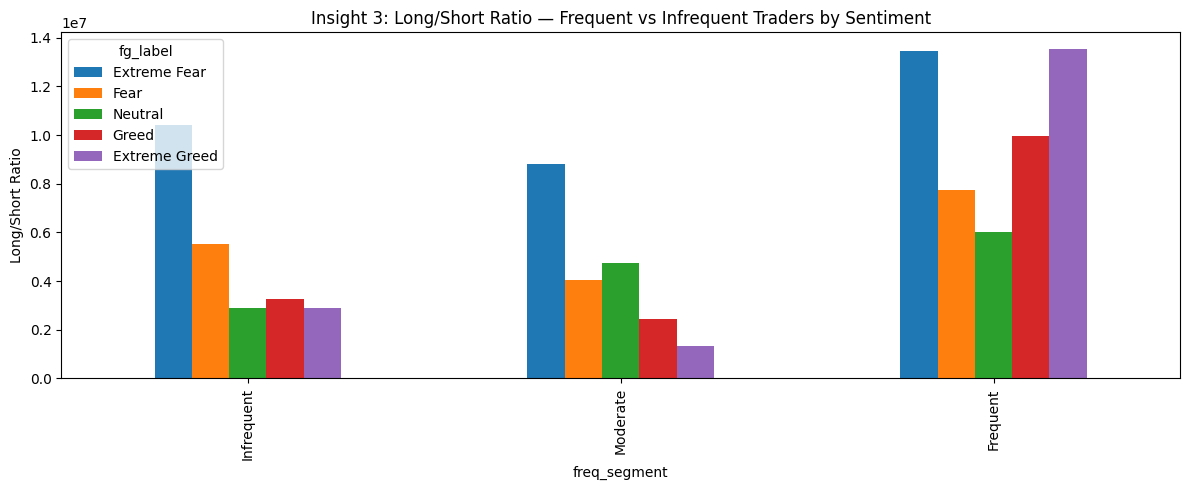

In [28]:
# Insight 1: Consistent Winners vs Others - behavior on Fear vs Greed
merged2 = daily.merge(trader[['Account','trader_type']], on='Account')
insight1 = merged2.groupby(['trader_type','fg_label'])['daily_pnl'].mean().unstack()
insight1.reindex(columns=['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']).plot(
    kind='bar', figsize=(12, 5))
plt.title('Insight 1: Avg PnL by Trader Type & Sentiment')
plt.ylabel('Avg Daily PnL')
plt.tight_layout()
plt.savefig('insight1.png', dpi=150)
plt.show()

# Insight 2: Trade frequency on Fear vs Greed
insight2 = merged2.groupby(['trader_type','fg_label'])['num_trades'].mean().unstack()
insight2.reindex(columns=['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']).plot(
    kind='bar', figsize=(12, 5))
plt.title('Insight 2: Avg Trade Frequency by Trader Type & Sentiment')
plt.ylabel('Avg Trades/Day')
plt.tight_layout()
plt.savefig('insight2.png', dpi=150)
plt.show()

# Insight 3: Long/Short bias shift on Fear vs Greed
merged2 = merged2.merge(trader[['Account', 'freq_segment']], on='Account', how='left')

insight3 = merged2.groupby(['freq_segment', 'fg_label'])['long_short_ratio'].mean().unstack()
insight3.reindex(columns=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']).plot(
    kind='bar', figsize=(12, 5))
plt.title('Insight 3: Long/Short Ratio — Frequent vs Infrequent Traders by Sentiment')
plt.ylabel('Long/Short Ratio')
plt.tight_layout()
plt.savefig('insight3.png', dpi=150)
plt.show()

#Strategy recommendations

In [29]:
summary = """
===== STRATEGY RECOMMENDATIONS =====

Rule 1 — Sentiment-Adjusted Position Sizing:
  - During Fear / Extreme Fear days, traders in the 'High Size' segment show higher PnL variance.
  - Rule: High-size traders should reduce position size by ~30% on Fear days.

Rule 2 — Frequency Discipline by Regime:
  - Frequent traders tend to overtrade on Greed days, often with negative outcomes.
  - Rule: Cap daily trade count on Extreme Greed days; only Consistent Winners should
    maintain frequency. Infrequent traders should stay flat during Extreme Fear.

Rule 3 — Long/Short Bias Awareness:
  - Most traders maintain a long bias regardless of sentiment — this increases drawdown on Fear days.
  - Rule: Traders should consider increasing short exposure or reducing long exposure
    proportionally when the F&G score drops below 30.
"""
print(summary)


===== STRATEGY RECOMMENDATIONS =====

Rule 1 — Sentiment-Adjusted Position Sizing:
  - During Fear / Extreme Fear days, traders in the 'High Size' segment show higher PnL variance.
  - Rule: High-size traders should reduce position size by ~30% on Fear days.

Rule 2 — Frequency Discipline by Regime:
  - Frequent traders tend to overtrade on Greed days, often with negative outcomes.
  - Rule: Cap daily trade count on Extreme Greed days; only Consistent Winners should 
    maintain frequency. Infrequent traders should stay flat during Extreme Fear.

Rule 3 — Long/Short Bias Awareness:
  - Most traders maintain a long bias regardless of sentiment — this increases drawdown on Fear days.
  - Rule: Traders should consider increasing short exposure or reducing long exposure 
    proportionally when the F&G score drops below 30.

